[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/01_probability_and_data.ipynb)

# 1. Probability and describing data

**What you should get out of this notebook**

- Think of a measurement as a sample from a probability distribution.
- Know what a PDF, a CDF and a quantile are, and how mean, variance and standard deviation summarise a distribution.
- Recognise a handful of distributions that turn up constantly: normal, uniform, exponential, Poisson, lognormal.
- Summarise a real data set with histograms, empirical CDFs and summary statistics, and fit a distribution to it.

**Tools introduced**

- `scipy.stats` distribution objects: `.pdf`, `.cdf`, `.ppf`, `.rvs`, `.mean()`, `.std()`, `.interval()`, `.fit()`
- `numpy` summaries: `np.mean`, `np.median`, `np.std`, `np.percentile`
- `stats.describe`, `stats.ecdf`, `stats.probplot`
- `pandas.read_csv` for loading a data set

## How to use these notebooks

Every notebook in this course opens in Google Colab by clicking the badge at the top. Nothing needs installing. Run a cell with **Shift+Enter**, and run cells in order from the top: later cells rely on earlier ones. You are encouraged to change numbers and re-run; that is the fastest way to build intuition. Each notebook ends with short exercises, with solutions hidden behind a *click to expand* link.

The first code cell of each notebook imports the libraries we use throughout and sets up a random number generator with a fixed seed, so that you get the same "random" numbers each time you run the notebook. Change the seed if you want to see different samples.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## Why statistics?

Measure anything in the laboratory or the field twice and you get two different numbers. The variation comes from a host of small effects we cannot control: electrical noise, hand tremor, the exact spot on the outcrop, the state of the atmosphere. Statistics is the discipline that treats such variation as *random*, and then asks precise questions:

- Given noisy measurements, what is our best estimate of the quantity of interest, and how uncertain is it? (Notebooks 2, 3, 5)
- Is a proposed model compatible with the data, or should it be rejected? (Notebook 4)
- Are two quantities related, and how strongly? (Notebook 6)
- How should we combine prior knowledge with new data? (Notebook 7)
- What can we do when the textbook formulae do not apply? (Notebook 8)

All of this rests on the idea of a **random variable**: a quantity whose value is not fixed, but which is described by a **probability distribution**. This notebook introduces the vocabulary and the software tools; the ideas will be used in every later notebook.

## Random variables and distributions

A random variable $X$ is characterised by its **cumulative distribution function (CDF)**

$$
F_X(x) = P(X \le x),
$$

the probability that $X$ takes a value no larger than $x$. The CDF rises from 0 to 1, and the probability that $X$ lies in an interval is a difference of CDF values:

$$
P(a < X \le b) = F_X(b) - F_X(a).
$$

For a **continuous** random variable, the derivative of the CDF is the **probability density function (PDF)**, $p_X(x) = F_X'(x)$. The probability of landing in a small interval of width $\mathrm{d}x$ is $p_X(x)\,\mathrm{d}x$, so the PDF tells you *where the probability is concentrated* even though the probability of any single exact value is zero. For a **discrete** random variable (a count, say) the analogue is a **probability mass function**, $P(X = k)$.

The inverse of the CDF is the **quantile function**. The $q$-quantile is the value $x_q$ such that $F_X(x_q) = q$. The median is the 0.5-quantile; the 0.025- and 0.975-quantiles bracket the central 95% of the distribution.

Two numbers summarise the location and width of a distribution:

$$
\text{mean:}\quad \mu = E[X] = \int x\, p_X(x)\, \mathrm{d}x, \qquad
\text{variance:}\quad \sigma^2 = E[(X-\mu)^2] = \int (x-\mu)^2\, p_X(x)\, \mathrm{d}x.
$$

The square root of the variance, $\sigma$, is the **standard deviation**, and has the same units as $X$. (For a discrete variable replace the integrals by sums.) Keep in mind that the mean and standard deviation are only *summaries*: two very different distributions can share the same $\mu$ and $\sigma$.

## Distributions in `scipy.stats`

`scipy.stats` provides objects for a very large number of distributions, all with the same interface. The pattern is to create a *frozen* distribution with its parameters fixed, and then call its methods. Here is the normal distribution with mean 2 and standard deviation 0.5 (the keyword names `loc` and `scale` are used by every `scipy.stats` distribution for the location and the width):

In [ ]:
X = stats.norm(loc=2.0, scale=0.5)

x = 2.4
print("PDF at x:              p(x) =", X.pdf(x))
print("CDF at x:         P(X <= x) =", X.cdf(x))
print("Quantile:  F^-1(0.975)      =", X.ppf(0.975))
print("Mean, std:                   ", X.mean(), X.std())
lo, hi = X.interval(0.95)
print(f"Central 95% interval:         ({lo:.3f}, {hi:.3f})")
print("Five random samples:         ", X.rvs(5, random_state=rng))

PDF at x:              p(x) = 0.5793831055229657
CDF at x:         P(X <= x) = 0.7881446014166033
Quantile:  F^-1(0.975)      = 2.979981992270027
Mean, std:                    2.0 0.5
Central 95% interval:         (1.020, 2.980)
Five random samples:          [2.1727921  2.41080907 2.16521854 1.34842138 2.45267793]


The names to remember are `pdf`, `cdf`, `ppf` (percent point function, i.e. the quantile function) and `rvs` (random variates). Let us plot the PDF and CDF side by side, and shade the probability of the event $1.5 < X \le 2.5$.

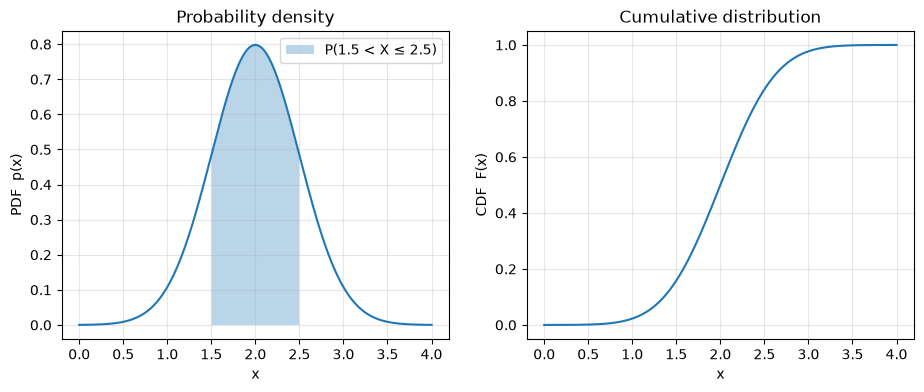

Shaded probability from the CDF: 0.6826894921370859


In [ ]:
xx = np.linspace(0, 4, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(xx, X.pdf(xx))
mask = (xx > 1.5) & (xx <= 2.5)
ax[0].fill_between(xx[mask], X.pdf(xx[mask]), alpha=0.3, label="P(1.5 < X ≤ 2.5)")
ax[0].set(xlabel="x", ylabel="PDF  p(x)", title="Probability density")
ax[0].legend()

ax[1].plot(xx, X.cdf(xx))
ax[1].set(xlabel="x", ylabel="CDF  F(x)", title="Cumulative distribution")
plt.show()

print("Shaded probability from the CDF:", X.cdf(2.5) - X.cdf(1.5))

The shaded probability is the difference of two CDF values, which is how one should always compute probabilities of intervals: never by integrating the PDF numerically when a CDF is available.

A useful fact worth memorising for the normal distribution: about 68% of the probability lies within one standard deviation of the mean, 95% within two, and 99.7% within three.

In [ ]:
Z = stats.norm()   # the standard normal: mean 0, standard deviation 1
for k in [1, 2, 3]:
    print(f"P(|Z| < {k}) = {Z.cdf(k) - Z.cdf(-k):.4f}")

P(|Z| < 1) = 0.6827
P(|Z| < 2) = 0.9545
P(|Z| < 3) = 0.9973


## A gallery of useful distributions

You will meet many distributions, but a small number account for most practical work. The plots below show their PDFs (or mass functions) with a note on where each arises.

| Distribution | `scipy.stats` | Parameters | Typical use |
|---|---|---|---|
| Normal | `norm(loc=μ, scale=σ)` | mean, standard deviation | measurement errors; sums of many small effects |
| Uniform | `uniform(loc=a, scale=b-a)` | interval $[a, b]$ | "no idea where in this range"; rounding errors |
| Exponential | `expon(scale=1/λ)` | rate $\lambda$ | waiting times between independent random events |
| Poisson | `poisson(mu=λt)` | expected count | number of events in a fixed interval |
| Lognormal | `lognorm(s=σ, scale=e^μ)` | $\mu$, $\sigma$ of $\ln X$ | positive, right-skewed quantities: grain sizes, permeabilities, ore grades |
| $t$, $\chi^2$ | `t(df)`, `chi2(df)` | degrees of freedom | sampling distributions of test statistics (Notebooks 2 and 4) |

Watch the parameterisation. `scipy` describes every distribution through `loc` and `scale`, which is not always the textbook parameterisation: the exponential distribution with rate $\lambda$ is `expon(scale=1/λ)`, and the lognormal needs `scale=np.exp(μ)`. When in doubt, check the documentation page for the distribution, or check `X.mean()` against what you expect.

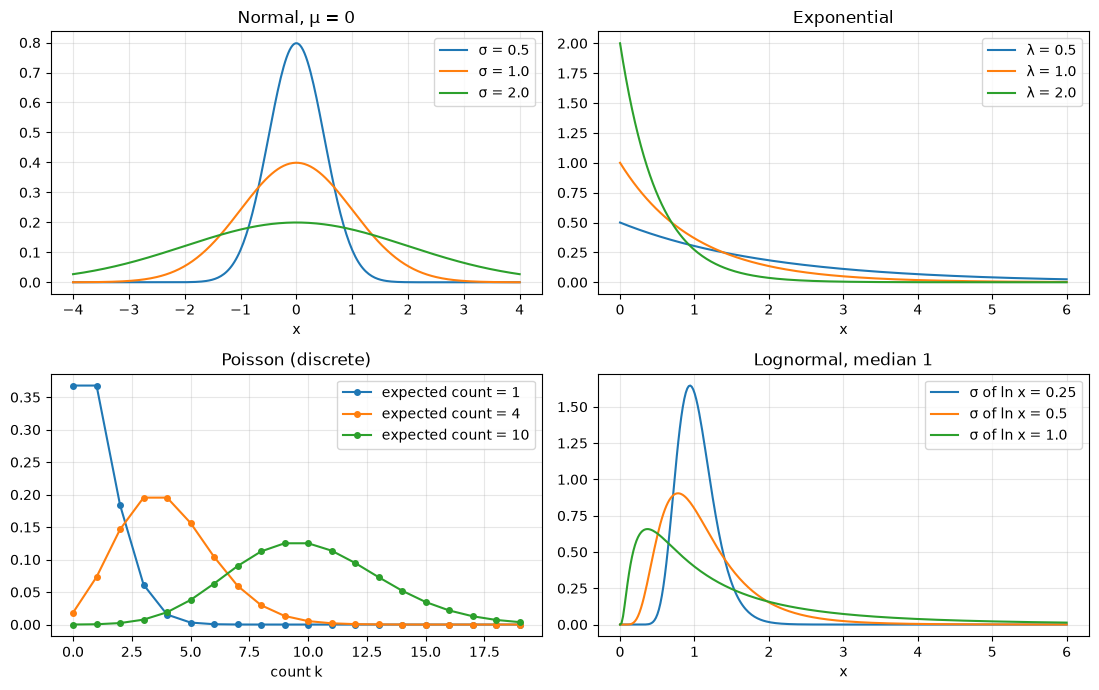

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.ravel()

xx = np.linspace(-4, 4, 300)
for s in [0.5, 1.0, 2.0]:
    ax[0].plot(xx, stats.norm(0, s).pdf(xx), label=f"σ = {s}")
ax[0].set(title="Normal, μ = 0", xlabel="x"); ax[0].legend()

xx = np.linspace(0, 6, 300)
for lam in [0.5, 1.0, 2.0]:
    ax[1].plot(xx, stats.expon(scale=1/lam).pdf(xx), label=f"λ = {lam}")
ax[1].set(title="Exponential", xlabel="x"); ax[1].legend()

k = np.arange(0, 20)
for mu in [1, 4, 10]:
    ax[2].plot(k, stats.poisson(mu).pmf(k), "o-", ms=4, label=f"expected count = {mu}")
ax[2].set(title="Poisson (discrete)", xlabel="count k"); ax[2].legend()

xx = np.linspace(0, 6, 300)
for s in [0.25, 0.5, 1.0]:
    ax[3].plot(xx, stats.lognorm(s=s, scale=1.0).pdf(xx), label=f"σ of ln x = {s}")
ax[3].set(title="Lognormal, median 1", xlabel="x"); ax[3].legend()

plt.tight_layout(); plt.show()

Two remarks. The Poisson and exponential distributions are two views of the same idea: if events occur independently at a constant average rate $\lambda$, the *number* of events in time $t$ is Poisson with mean $\lambda t$, and the *time between* successive events is exponential with rate $\lambda$. Earthquakes above some magnitude in a large region, radioactive decays and cosmic-ray hits are all approximately of this type. Secondly, the lognormal distribution is what you get when you exponentiate a normal variable. Quantities that are products of many small random factors, or that are positive and span orders of magnitude, are often close to lognormal. For such data it is usually wise to work with the logarithm.

## From data to distributions: the Old Faithful geyser

So far we have talked about distributions we chose. In practice we have data, and want to find out what distribution might have produced it. We will use a small classic data set: 272 eruptions of the Old Faithful geyser in Yellowstone National Park, recording the duration of each eruption (minutes) and the waiting time until the next eruption (minutes). The data are stored in this course's GitHub repository, and `pandas` can read them directly from the URL.

In [ ]:
faithful = pd.read_csv(DATA + "old_faithful.csv")
print(faithful.shape)
faithful.head()

(272, 2)


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


The first thing to do with any new data set is to *look at it*. A **histogram** counts how many values fall in each of a set of bins. With `density=True` the bar areas sum to one so that it can be compared with a PDF. The **empirical CDF** is the fraction of the data at or below each value, a step function that estimates the true CDF; it needs no choice of bins, which is an advantage.

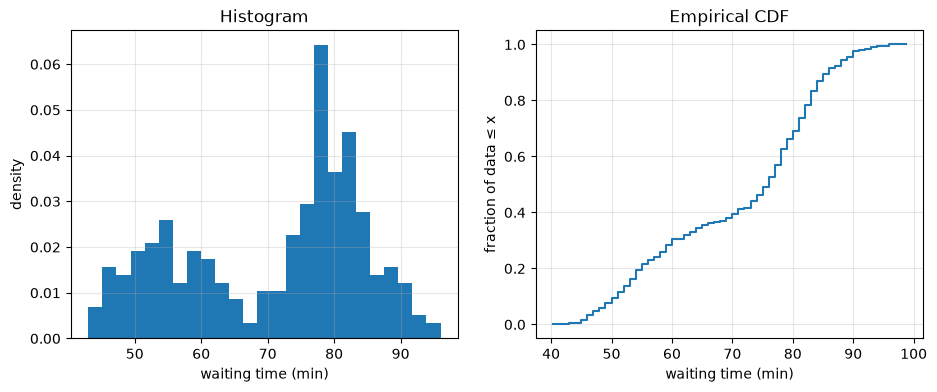

In [ ]:
waiting = faithful["waiting"].to_numpy()
duration = faithful["eruptions"].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(waiting, bins=25, density=True)
ax[0].set(xlabel="waiting time (min)", ylabel="density", title="Histogram")
stats.ecdf(waiting).cdf.plot(ax[1])
ax[1].set(xlabel="waiting time (min)", ylabel="fraction of data ≤ x", title="Empirical CDF")
plt.show()

The waiting times are **bimodal**: there is a cluster of short waits around 55 minutes and a larger cluster around 80 minutes. Now compute the standard summary statistics.

In [ ]:
print(f"mean   = {np.mean(waiting):.2f}")
print(f"median = {np.median(waiting):.2f}")
print(f"std    = {np.std(waiting, ddof=1):.2f}")     # ddof=1 gives the sample standard deviation
print(f"quartiles (25%, 50%, 75%) = {np.percentile(waiting, [25, 50, 75])}")

d = stats.describe(waiting)      # several summaries at once
print(f"n = {d.nobs}, min/max = ({d.minmax[0]}, {d.minmax[1]}), mean = {d.mean:.2f}, variance = {d.variance:.2f}, skewness = {d.skewness:.2f}")

mean   = 70.90
median = 76.00
std    = 13.59
quartiles (25%, 50%, 75%) = [58. 76. 82.]
n = 272, min/max = (43, 96), mean = 70.90, variance = 184.82, skewness = -0.42


The mean waiting time is about 71 minutes, and yet very few eruptions have waiting times near 71 minutes. The summary is correct but uninformative; the histogram tells you far more. **Always plot the data before computing statistics.**

Notice `ddof=1` in the standard deviation. By default `np.std` divides by $n$, whereas the usual *sample* standard deviation divides by $n-1$, which makes it an unbiased estimator of the variance. The difference is negligible for large $n$, but the $n-1$ version is the one you should use when estimating the spread of a population from a sample. (`pandas` and `stats.describe` use $n-1$ by default; `numpy` does not.)

## Fitting a distribution to data

Every `scipy.stats` distribution has a `.fit` method that finds the parameters making the data most probable: this is *maximum likelihood* estimation, a topic for Notebook 5. For the normal distribution the fitted parameters are simply the sample mean and standard deviation. Let us fit a normal distribution to the waiting times and see how it fares.

fitted normal: μ = 70.90, σ = 13.57


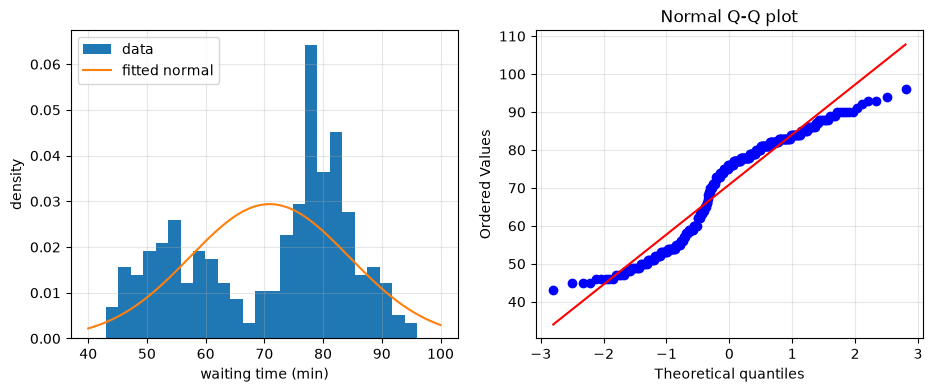

In [ ]:
mu_hat, sigma_hat = stats.norm.fit(waiting)
print(f"fitted normal: μ = {mu_hat:.2f}, σ = {sigma_hat:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xx = np.linspace(40, 100, 300)
ax[0].hist(waiting, bins=25, density=True, label="data")
ax[0].plot(xx, stats.norm(mu_hat, sigma_hat).pdf(xx), label="fitted normal")
ax[0].set(xlabel="waiting time (min)", ylabel="density"); ax[0].legend()

stats.probplot(waiting, dist="norm", plot=ax[1])
ax[1].set(title="Normal Q-Q plot")
plt.show()

The left panel shows the mismatch directly. The right panel is a **quantile-quantile (Q-Q) plot**: the sorted data are plotted against the quantiles a normal distribution would predict. Data drawn from a normal distribution give a straight line; the S-shaped kink here is the signature of the two modes. Q-Q plots are the most sensitive visual check of a distributional assumption, and you should use them whenever a method assumes normality.

If we split the eruptions by duration the picture is much cleaner. Eruptions lasting under three minutes are followed by short waits, longer eruptions by long waits, and each group on its own is reasonably well described by a normal distribution.

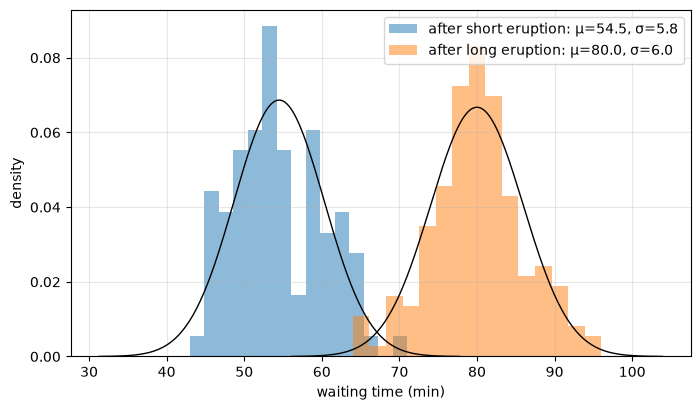

In [ ]:
short = waiting[duration < 3]
long_ = waiting[duration >= 3]

fig, ax = plt.subplots()
for grp, name in [(short, "after short eruption"), (long_, "after long eruption")]:
    m, s = stats.norm.fit(grp)
    ax.hist(grp, bins=15, density=True, alpha=0.5, label=f"{name}: μ={m:.1f}, σ={s:.1f}")
    xx = np.linspace(m - 4*s, m + 4*s, 200)
    ax.plot(xx, stats.norm(m, s).pdf(xx), color="k", lw=1)
ax.set(xlabel="waiting time (min)", ylabel="density"); ax.legend()
plt.show()

This is a general lesson: a distribution that looks strange is often a **mixture** of simpler ones, and finding the variable that separates them is a scientific result in its own right.

## A second example: times between large earthquakes

The repository also holds the USGS catalogue of all earthquakes of magnitude 5 or greater from 2014 to 2023. We take the events of magnitude 6.5 and above, compute the time between successive events, and compare with the exponential distribution that a constant-rate random process would produce.

443 events of M ≥ 6.5, mean gap = 8.25 days


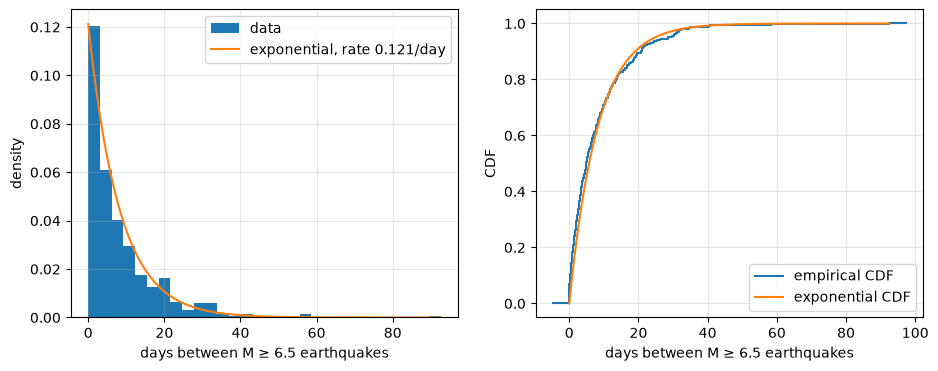

fraction of gaps shorter than one day: observed 0.192, exponential model 0.114


In [ ]:
quakes = pd.read_csv(DATA + "usgs_earthquakes_M5_2014_2023.csv", parse_dates=["time"])
big = quakes[quakes["mag"] >= 6.5].sort_values("time")
t = big["time"].to_numpy()
gaps = np.diff(t) / np.timedelta64(1, "D")     # inter-event times in days
print(f"{len(big)} events of M ≥ 6.5, mean gap = {gaps.mean():.2f} days")

lam = 1 / gaps.mean()                           # maximum likelihood rate estimate (events per day)
E = stats.expon(scale=1/lam)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(gaps, bins=30, density=True, label="data")
xx = np.linspace(0, gaps.max(), 300)
ax[0].plot(xx, E.pdf(xx), label=f"exponential, rate {lam:.3f}/day")
ax[0].set(xlabel="days between M ≥ 6.5 earthquakes", ylabel="density"); ax[0].legend()

stats.ecdf(gaps).cdf.plot(ax[1], label="empirical CDF")
ax[1].plot(xx, E.cdf(xx), label="exponential CDF")
ax[1].set(xlabel="days between M ≥ 6.5 earthquakes", ylabel="CDF"); ax[1].legend()
plt.show()

print(f"fraction of gaps shorter than one day: observed {np.mean(gaps < 1):.3f}, exponential model {E.cdf(1):.3f}")

The agreement is good but not perfect. Nearly twice as many gaps are shorter than one day as the exponential model predicts, because large earthquakes trigger aftershocks, so events are not entirely independent. This is typical of real data: an idealised model captures most of the behaviour, and the *departures* from it are where the physics lies. Deciding whether such departures are real or just sampling noise is the job of hypothesis testing, in Notebook 4.

## Summary

- A random variable is described by its CDF (or equivalently its PDF); probabilities of intervals are differences of CDF values.
- Mean and standard deviation summarise location and spread, but a histogram or empirical CDF shows far more.
- `scipy.stats` provides every common distribution with the same interface: `pdf`, `cdf`, `ppf`, `rvs`, `fit`.
- Q-Q plots are the sharpest visual test of whether data follow an assumed distribution.
- Real data usually follow an idealised model *approximately*; look for structure in the departures.

**Further reading.** The [`scipy.stats` tutorial](https://docs.scipy.org/doc/scipy/tutorial/stats.html) is short and worth reading in full. Any introductory statistics text covers this material; for Earth scientists, *Statistics and Data Analysis in Geology* by J. C. Davis is a classic.

## Exercises

### Exercise 1

A laboratory balance has random errors that are normally distributed with standard deviation 0.3 mg. A sample is weighed once. What is the probability that the reading is more than 0.5 mg from the true mass? What error is exceeded only 1% of the time? Use the `cdf` and `ppf` methods.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

By symmetry the probability of an error beyond $\pm 0.5$ mg is $2\,[1 - F(0.5)]$. For the second part we want the 0.995-quantile (so that 0.5% lies in each tail).

```python
E = stats.norm(loc=0, scale=0.3)
p_outside = 2 * (1 - E.cdf(0.5))          # or 2 * E.cdf(-0.5)
print(f"P(|error| > 0.5 mg) = {p_outside:.4f}")
print(f"error exceeded 1% of the time: ±{E.ppf(0.995):.3f} mg")
```

About 9.6% of readings are off by more than 0.5 mg, and the error exceeds ±0.77 mg only 1% of the time.

</details>

### Exercise 2

Simulate 10,000 samples from a lognormal distribution with `s=1` and `scale=1` (so that $\ln X$ is standard normal). Compare the sample mean, median and mode with the exact values (`X.mean()`, `X.median()`, and the mode $e^{\mu - \sigma^2}$). Plot a histogram of the samples, and a histogram of their logarithms. Which summary statistic best describes a "typical" value?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
X = stats.lognorm(s=1, scale=1)
x = X.rvs(10_000, random_state=rng)
print(f"mean:   sample {x.mean():.3f}   exact {X.mean():.3f}")
print(f"median: sample {np.median(x):.3f}   exact {X.median():.3f}")
print(f"mode:   exact {np.exp(0 - 1**2):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(x, bins=100, density=True); ax[0].set(xlabel="x", xlim=(0, 15))
ax[1].hist(np.log(x), bins=50, density=True); ax[1].set(xlabel="ln x")
plt.show()
```

The mean (about 1.65) is pulled upward by the long right tail and is larger than most of the samples. The median (1) is a much better description of a typical value, and the mode (0.37) is where the density peaks. For skewed data quote the median, or work with the logarithm, where the distribution is symmetric and the mean and median agree.

</details>

### Exercise 3

Using the earthquake catalogue, count how many magnitude 6.5+ earthquakes occurred in each calendar year from 2014 to 2023. If the events were a constant-rate random process, the counts would be Poisson distributed with mean equal to the average annual count. Compare the observed standard deviation of the counts with the Poisson prediction $\sqrt{\text{mean}}$. Hint: `big["time"].dt.year` gives the year of each event, and `np.bincount` or `pandas` `value_counts` counts them.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
years = big["time"].dt.year
counts = years.value_counts().sort_index()
print(counts)
print(f"mean annual count = {counts.mean():.1f}")
print(f"observed std      = {counts.std():.2f}")
print(f"Poisson std       = {np.sqrt(counts.mean()):.2f}")
```

The observed spread is somewhat larger than a Poisson process would give, which is again the signature of clustering (aftershock sequences make some years unusually busy). With only ten years the comparison is rough; Notebook 4 shows how to judge whether such a difference is significant.

</details>